# Yen Safe Haven — the quant teardown 🇯🇵

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2022 failure?: Confirmed](https://img.shields.io/badge/2022_failure%3F-Confirmed-8b949e?style=flat-square)

**Claim.** Risk-off forces yen-funded carry books to buy back JPY: *when stocks crash, the yen rallies* — a free crash hedge. **Tape.** Daily yfinance `JPY=X` (USDJPY spot; the yen's return is **minus** the USDJPY change; price-only, labeled) + `SPY` (total-return) + `^IRX` (13w bill = the carry / foregone-rate proxy; JP short rates ~0 nearly all sample) + `^TNX`, 1996-10-30 → 2026-06-30 (as-of 2026-06-30, last complete month), 7,418 joint daily returns / 356 months. No survivorship (one pair, one index). **Execution.** The hedge is a *static sleeve held in advance* — no timing signal, hence no lag to apply (the one documented execution convention); event and quintile returns use same-close daily returns. Fingerprint `6d34d723338d` ([docs/results.md](../docs/results.md)). Sibling: [69-safe-haven](../../69-safe-haven/README.md) (gold — same question, store-of-value mechanism).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from yen_safe_haven import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPE = data.load_real()                  # as-of'd daily tape (usdjpy, spy, irx, tnx)
    RETS = st.to_returns(TAPE)
    M = st.monthly_returns(TAPE)
else:
    TAPE = RETS = M = None
print("real tape cached:", HAVE_REAL,
      "| daily returns:", (0 if RETS is None else len(RETS)),
      "| months:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1996-10-30', 'end': '2026-06-30', 'years': 29.4, 'n_days': 7418, 'n_months': 356, 'fingerprint': '6d34d723338d', 'as_of': '2026-06-30', 'beta_dn': -0.113, 't_dn': -4.62, 'beta_up': -0.046, 't_up': -1.94, 'beta_all': -0.08, 't_all': -4.45, 'r2': 0.02, 'nw_lags': 10, 'q_means': [12.17, -1.35, -3.06, -4.2, -6.64], 'spy_q1_bps': -157.1, 't_q1_q5': 5.81, 't_q1_mid': 5.81, 'dn_bps': -8.51, 'up_bps': -17.16, 'n_dn': 128, 'n_up': 228, 't_month': 0.26, 'dec_n': 35, 'dec_spy': -7.93, 'dec_jpy': 0.39, 'dec_hit': 57, 'drop_all_ev_t': -4.27, 'drop_all_ev_welch': 3.97, 'drop_all_ev_n': 5924, 'drop100_t': -3.02, 'drop100_welch': 4.68, 'boot_welch_mean': 5.72, 'boot_frac_gt2': 100, 'sub': [('1996-2010', 3529, -0.179, -6.18, 24.04, 5.57), ('2011-2026', 3889, -0.022, -0.89, -0.83, 1.03), ('2016-2026', 2633, -0.011, -0.38, -0.92, 0.16)], 'events': [('GFC deleveraging (Lehman -> year-end)', '2008-09-12', '2008-12-31', -27.43, 19.07, True), ('Aug-2015 (CNY deval + flash crash)', '2015-08-10', '2015-08-25', -11.07, 4.56, True), ('COVID risk-off leg (peak -> 03-09)', '2020-02-19', '2020-03-09', -18.95, 5.75, True), ('COVID dollar scramble (03-09 -> trough)', '2020-03-09', '2020-03-23', -18.22, -5.91, False), ('2022 bear market (top -> trough)', '2022-01-03', '2022-10-12', -24.5, -21.07, False), ('Aug-2024 carry unwind (BOJ hike -> crash)', '2024-07-31', '2024-08-05', -6.07, 4.87, True)], 'hi_beta_dn': -0.097, 'hi_t_dn': -3.83, 'hi_n': 3310, 'hi_share': 45, 'lo_beta_dn': -0.123, 'lo_t_dn': -3.59, 'lo_n': 4108, 'fell_bps': 112.53, 'rose_bps': -150.06, 'n_fell': 69, 'n_rose': 59, 't_gap': 5.14, 'spot_ann': -2.2, 'excess_ann': -4.34, 'net_ann': -4.74, 'avg_bill': 2.21, 'expense_bps': 40, 'spy_2022': -24.5, 'jpy_2022': -21.07, 'ratio_2022': 86, 'syn': [(0.0, 0.015, 1.32, -3.22, -1.59), (0.3, -0.284, -25.91, 45.74, 20.75)]}


real tape cached: True | daily returns: 7418 | months: 356


## 1 · The conditional (downside) beta — HAC/Newey-West

Piecewise daily regression `jpy ~ a + b_dn·min(spy,0) + b_up·max(spy,0)`; NW lags by the `4(n/100)^{2/9}` plug-in (10 on the full sample). The safe-haven claim is **b_dn < 0**.

> 💡 **In plain words:** we let the yen respond *differently* to stock drops and stock rallies, and ask whether the drop-response is really there once we account for the fact that currency noise clusters.

In [2]:
if HAVE_REAL:
    B = st.downside_beta(RETS)
    print(f"downside beta {B['beta_dn']:+.3f}  (HAC t = {B['t_dn']:+.2f})")
    print(f"upside   beta {B['beta_up']:+.3f}  (HAC t = {B['t_up']:+.2f})")
    print(f"plain    beta {B['beta_all']:+.3f}  (HAC t = {B['t_all']:+.2f})   "
          f"R2={B['r2']:.3f}  n={B['n']:,}  NW lags={B['lags']}")
else:
    print('cache missing - frozen:', R['beta_dn'], R['t_dn'])

downside beta -0.113  (HAC t = -4.62)
upside   beta -0.046  (HAC t = -1.94)
plain    beta -0.080  (HAC t = -4.45)   R2=0.020  n=7,418  NW lags=10


**b_dn = -0.113, HAC t = -4.62** — decisively past the desk's t ≥ 2 bar, on 29.4 years of daily tape with nothing survivor-selected. The upside leg (-0.046, t = -1.94) is less than half the size: the yen is a *bad-day* currency, exactly as the legend says. This full-sample number is **not** a two-episode mirage — it survives dropping all six named crash years at once (n = 5,924, HAC t = **-4.27**), dropping the 100 worst SPY days (HAC t = **-3.02**), and a 20-seed stationary bootstrap (Welch t mean **+5.72**, 100% of seeds > 2).

### 1b · …but the daily signal has decayed to zero

The one thing the full-sample *t* hides is **when** the effect happened. Re-estimate the downside beta on calendar halves and on the recent decade — the whole signal is pre-2011, and it is statistically **absent** since.

> 💡 **In plain words:** graded on the whole tape it clears the bar; graded on a live, forward basis it does not. The reflex faded as Japan's rate-differential regime changed. That is why the Signal axis is **Mixed**, not Real.

In [3]:
if HAVE_REAL:
    for lo, hi in [(1996, 2010), (2011, 2026), (2016, 2026)]:
        sub = RETS[(RETS.index.year >= lo) & (RETS.index.year <= hi)]
        b = st.downside_beta(sub); q = st.quintile_ladder(sub)
        print(f'  {lo}-{hi}: n={b["n"]:>5,}  beta_dn={b["beta_dn"]:+.3f} '
              f'(HAC t={b["t_dn"]:+.2f})  Q1={q["q1_bps"]:+6.2f} bps/day  '
              f'Welch t(Q1 vs mid)={q["t_q1_vs_mid"]:+.2f}')
else:
    for e in R['sub']:
        print('  frozen:', e)

  1996-2010: n=3,529  beta_dn=-0.179 (HAC t=-6.18)  Q1=+24.04 bps/day  Welch t(Q1 vs mid)=+5.57
  2011-2026: n=3,889  beta_dn=-0.022 (HAC t=-0.89)  Q1= -0.83 bps/day  Welch t(Q1 vs mid)=+1.03


  2016-2026: n=2,633  beta_dn=-0.011 (HAC t=-0.38)  Q1= -0.92 bps/day  Welch t(Q1 vs mid)=+0.16


**1996-2010** carries the whole thing (HAC t = **-6.18**, Q1 = **+24.04 bps/day**). **2011-2026** — half the sample, 15 years — is a flat zero (HAC t = **-0.89**, Q1 = **-0.83**, Welch t = **+1.03**), and **2016-2026** is deader still (HAC t = **-0.38**). The flight-to-yen is real in the tape but **gone from the last decade** — a fading signal, not a live one.

## 2 · Quintile ladder + the monthly horizon

Mean JPY return per SPY-day quintile (Welch t across buckets), then the same idea at the monthly horizon — where a *bear-market hedge* would have to live.

> 💡 **In plain words:** the staircase below is the daily hedge. Then we zoom out to whole months and it's gone — the yen protects you for hours, not quarters.

In [4]:
if HAVE_REAL:
    Q = st.quintile_ladder(RETS)
    for k, (mu, n) in enumerate(zip(Q['means_bps'], Q['ns']), start=1):
        print(f'  Q{k}: {mu:+6.2f} bps/day  (n={n:,})')
    print(f"  Welch t (Q1 vs Q5)  = {Q['t_q1_vs_q5']:+.2f}")
    print(f"  Welch t (Q1 vs mid) = {Q['t_q1_vs_mid']:+.2f}")
    DM = st.down_month_split(M)
    print(f"\n  monthly: down-months (n={DM['n_dn']}) {DM['dn_bps']:+.2f} bps/mo vs "
          f"up-months (n={DM['n_up']}) {DM['up_bps']:+.2f} bps/mo  ->  Welch t = {DM['t_dn_vs_up']:+.2f}")
    print(f"  worst-decile SPY months (n={DM['dec_n']}, SPY {DM['dec_spy_pct']:+.2f}%/mo): "
          f"JPY {DM['dec_jpy_pct']:+.2f}%/mo, up {DM['dec_hit']*100:.0f}% of the time")
else:
    print('cache missing - frozen ladder:', R['q_means'])

  Q1: +12.17 bps/day  (n=1,484)
  Q2:  -1.35 bps/day  (n=1,483)
  Q3:  -3.06 bps/day  (n=1,484)
  Q4:  -4.20 bps/day  (n=1,483)
  Q5:  -6.64 bps/day  (n=1,484)
  Welch t (Q1 vs Q5)  = +5.81
  Welch t (Q1 vs mid) = +5.81

  monthly: down-months (n=128) -8.51 bps/mo vs up-months (n=228) -17.16 bps/mo  ->  Welch t = +0.26
  worst-decile SPY months (n=35, SPY -7.93%/mo): JPY +0.39%/mo, up 57% of the time


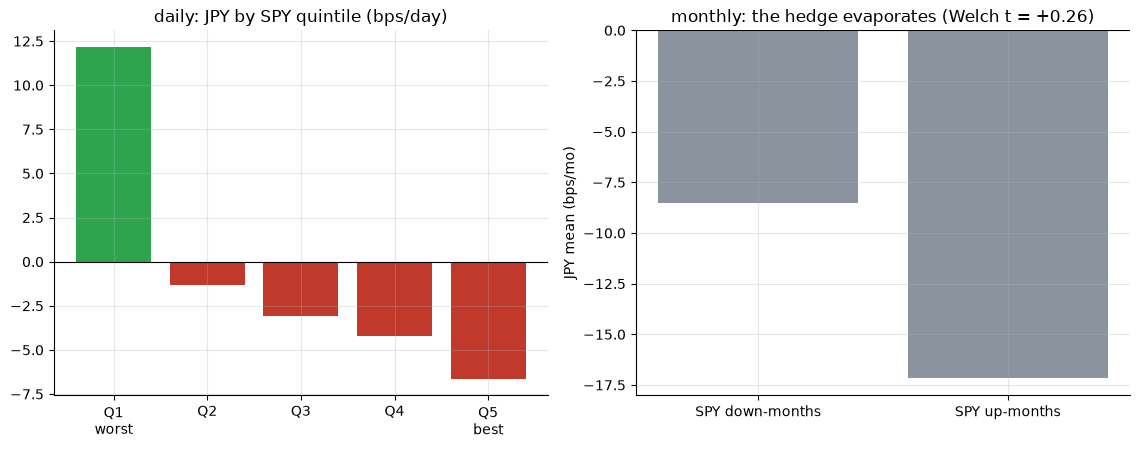

In [5]:
if HAVE_REAL:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
    means = Q['means_bps']
    axes[0].bar(range(1, 6), means, color=[GREEN if v > 0 else RED for v in means])
    axes[0].axhline(0, color='k', lw=.8)
    axes[0].set_xticks(range(1, 6)); axes[0].set_xticklabels(['Q1\nworst', 'Q2', 'Q3', 'Q4', 'Q5\nbest'])
    axes[0].set_title('daily: JPY by SPY quintile (bps/day)')
    dn = M.loc[M['spy'] < 0, 'jpy'] * 1e4
    up = M.loc[M['spy'] >= 0, 'jpy'] * 1e4
    axes[1].bar(['SPY down-months', 'SPY up-months'], [dn.mean(), up.mean()], color=[GREY, GREY])
    axes[1].axhline(0, color='k', lw=.8)
    axes[1].set_title(f'monthly: the hedge evaporates (Welch t = {DM["t_dn_vs_up"]:+.2f})')
    axes[1].set_ylabel('JPY mean (bps/mo)')
    plt.tight_layout(); plt.show()

The daily ladder is emphatic (Q1 = **+12.17** bps/day, Welch t vs Q5 = **+5.81**). The monthly contrast is **t = 0.26** — nothing. Worst-decile months: **+0.39%/mo**, up only **57%** of the time (gold's crash coin-flip, again). The negative drift eats the flight-to-quality within weeks.

## 3 · Event studies

Window dates hardcoded in `data.EVENTS` (BIS-sourced framing in the comments); returns always computed from the tape.

In [6]:
if HAVE_REAL:
    for e in st.event_table(TAPE):
        tick = 'HEDGED' if e['hedged'] else 'FAILED'
        print(f"  {e['label']:<44s} {e['start']} -> {e['end']}: "
              f"SPY {e['spy_pct']:+7.2f}%  JPY {e['jpy_pct']:+7.2f}%  [{tick}]")
else:
    for lab, s, e_, sp, jp, h in R['events']:
        print(f'  {lab:<44s} {s} -> {e_}: SPY {sp:+7.2f}%  JPY {jp:+7.2f}%')

  GFC deleveraging (Lehman -> year-end)        2008-09-12 -> 2008-12-31: SPY  -27.43%  JPY  +19.07%  [HEDGED]
  Aug-2015 (CNY deval + flash crash)           2015-08-10 -> 2015-08-25: SPY  -11.07%  JPY   +4.56%  [HEDGED]
  COVID risk-off leg (SPY peak -> 03-09)       2020-02-19 -> 2020-03-09: SPY  -18.95%  JPY   +5.75%  [HEDGED]
  COVID dollar scramble (03-09 -> trough)      2020-03-09 -> 2020-03-23: SPY  -18.22%  JPY   -5.91%  [FAILED]
  2022 bear market (SPY top -> trough)         2022-01-03 -> 2022-10-12: SPY  -24.50%  JPY  -21.07%  [FAILED]
  Aug-2024 carry unwind (BOJ hike -> crash)    2024-07-31 -> 2024-08-05: SPY   -6.07%  JPY   +4.87%  [HEDGED]


Four clean hedges (2008 **+19.1%** against −27.4%; Aug-2015; COVID's first leg; Aug-2024) and two failures with a shared signature: the selloff being driven by the **dollar side** — the Mar-2020 funding scramble (BIS Bulletin 2) and the 2022 rate-shock bear.

> 💡 **In plain words:** when the panic is about *growth*, money runs to the yen. When the panic is about *dollars* (everyone needs them, or they suddenly yield 4% more), money runs **away** from the yen — crash or no crash.

## 4 · Regime splits — what turns the hedge off

**(A) The carry-stock proxy.** If the mechanism were *only* carry unwind, the downside beta should vanish when the USD-JPY differential is ~0 (US ZIRP: nothing to unwind).
**(B) Yield direction.** Among SPY down-months: growth scares (10y fell) vs rate shocks (10y rose).

In [7]:
if HAVE_REAL:
    RG = st.carry_regime_split(RETS, cut=2.0)
    for tag, b, n in [(f"bill >= 2% ({RG['share_hi']*100:.0f}% of days)", RG['hi'], RG['n_hi']),
                      ('bill <  2% (ZIRP)', RG['lo'], RG['n_lo'])]:
        print(f"  {tag:<26s} n={n:>5,}  beta_dn={b['beta_dn']:+.3f} (HAC t={b['t_dn']:+.2f})")
    YD = st.yield_direction_split(M)
    print(f"\n  down-months, 10y FELL (growth scare, n={YD['n_fell']}): JPY {YD['fell_bps']:+8.2f} bps/mo")
    print(f"  down-months, 10y ROSE (rate shock,   n={YD['n_rose']}): JPY {YD['rose_bps']:+8.2f} bps/mo")
    print(f"  Welch t of the gap = {YD['t_gap']:+.2f}")

  bill >= 2% (45% of days)   n=3,310  beta_dn=-0.097 (HAC t=-3.83)
  bill <  2% (ZIRP)          n=4,108  beta_dn=-0.123 (HAC t=-3.59)

  down-months, 10y FELL (growth scare, n=69): JPY  +112.53 bps/mo
  down-months, 10y ROSE (rate shock,   n=59): JPY  -150.06 bps/mo
  Welch t of the gap = +5.14


**(A)** The hedge survives *both* regimes (fat differential: b_dn = -0.097, t = -3.83; ZIRP: -0.123, t = -3.59) — so the daily reflex is general risk-off demand (Habib-Stracca's net-foreign-asset story), **not** purely the size of the carry book. The folk *mechanism* is at best half the story even when the folk *fact* is right.

**(B)** The operative switch is the yield direction: **+112.5 bps/mo** when yields fell vs **-150.1** when they rose (Welch t = **+5.14**). A rate-shock bear *widens* the differential all the way down — carry gets more attractive during the crash. That is 2022, mechanically.

> 💡 **In plain words:** the yen is insurance against "the economy is breaking", not against "my stocks are falling". In 2022 stocks fell *because* rates rose — the one crash flavor this insurance is guaranteed to skip.

## 5 · Tradability — the carry bill

Excess-vs-excess: the static sleeve's return = JPY spot (price-only; JPY deposits ~0) **minus** the US bill the dollars would have earned, minus a 40 bps/yr FXY-style expense. No timing signal → no lag; one entry, <1 bp/yr amortised.

In [8]:
if HAVE_REAL:
    HC = st.hedge_cost(RETS)
    print(f"  JPY spot (price-only): {HC['spot_ann_pct']:+.2f}%/yr over {HC['years']:.1f} years")
    print(f"  minus avg bill {HC['avg_bill_pct']:.2f}%/yr  ->  excess {HC['excess_ann_pct']:+.2f}%/yr")
    print(f"  minus {HC['expense_bps']:.0f} bps expense    ->  net    {HC['net_ann_pct']:+.2f}%/yr")

  JPY spot (price-only): -2.20%/yr over 29.4 years
  minus avg bill 2.21%/yr  ->  excess -4.34%/yr
  minus 40 bps expense    ->  net    -4.74%/yr


**-4.74%/yr net, for 29.4 years.** The insurance premium is the size of the equity risk premium itself — and section 2 showed the monthly hedge value is statistically zero. Access is not the issue (FXY, futures, spot FX all work at retail); the **negative carry is the position**. Stamp: **MIRAGE**.

## 6 · Synthetic control — machinery proof *(never market evidence)*

Seeded world (`synthetic_world`, seed 615): the planted yen earns `hedge × |SPY|` on SPY down days only. The null (`hedge = 0`) must stay flat; the plant must light up.

In [9]:
for hedge in (0.0, 0.30):
    world = data.synthetic_world(hedge=hedge, seed=615)
    r = st.to_returns(world)
    b = st.downside_beta(r)
    q = st.quintile_ladder(r)
    print(f'  hedge={hedge:.2f}: beta_dn={b["beta_dn"]:+.3f} (HAC t={b["t_dn"]:+.2f})  '
          f'Q1={q["q1_bps"]:+.2f} bps/day  Welch t(Q1 vs Q5)={q["t_q1_vs_q5"]:+.2f}')

  hedge=0.00: beta_dn=+0.015 (HAC t=+1.32)  Q1=-3.22 bps/day  Welch t(Q1 vs Q5)=-1.59


  hedge=0.30: beta_dn=-0.284 (HAC t=-25.91)  Q1=+45.74 bps/day  Welch t(Q1 vs Q5)=+20.75


Null: t = +1.32 (flat). Plant: t = -25.91. The detector cannot manufacture a safe haven from noise and cannot miss a real one — so the real-tape t = -4.62 is a property of the tape, not the harness.

## Verdict

- **Signal — MIXED (real on the full tape, decayed and fast-twitch).** b_dn = **-0.113** (HAC t = **-4.62**), Q1 = **+12.17 bps/day** (Welch t = **+5.81**); no survivorship, and robust to dropping every episode and to bootstrap — a genuine signal, not a lucky seed. But **non-stationary**: 1996-2010 carries it (t = -6.18) while 2011-2026 is a flat zero (t = -0.89) and 2016-2026 is dead (t = -0.38). Monthly horizon: absent in every era (t = 0.26).
- **Tradability — MIRAGE.** **-4.74%/yr net** for 29.4 years, zero monthly hedge value, and mechanical failure in rate-shock bears.
- **2022 failure — CONFIRMED.** JPY **-21.07%** vs SPY **-24.50%** top→trough (86% as large a loss), explained by the yield-direction split (Welch t = +5.14).

*Every number above is printed by [examples/verify.py](../examples/verify.py) and frozen in [docs/results.md](../docs/results.md). Not investment advice.*